# 05 · EDA — Agua infiltrada por masa

`gold.agua_infiltrada_masa_subterranea` — recarga por infiltracion de lluvia (m3/mes) por masa: `lluvia_mm x sum(area_km2 x coef) x 1000`. Derivada de la lluvia (mismo pattern que la feature de lluvia).


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "agua_infiltrada_masa_subterranea.csv", infer_schema_length=None)
print("shape:", df.shape)
print("masas:", df["cod_masa"].n_unique())
df.head(5)


shape: (11450, 4)
masas: 84


cod_masa,anio,mes,agua_infiltrada_m3
str,i64,i64,f64
"""1806M1""",2021,6,369172.04
"""1815M2""",2016,9,306762.868
"""1814M4""",2024,6,176622.303
"""1804M2""",2018,7,167706.92
"""1821M2""",2016,7,0.0


In [3]:
print("Nulos por columna:")
df.null_count()


Nulos por columna:


cod_masa,anio,mes,agua_infiltrada_m3
u32,u32,u32,u32
0,0,0,0


In [4]:
# Cobertura temporal
df.group_by("cod_masa").agg(anio_min=pl.col("anio").min(), anio_max=pl.col("anio").max(), n=pl.len()).sort("n").head(5)

# Total anual en hm3
anual = (df.with_columns((pl.col("agua_infiltrada_m3") / 1_000_000).alias("infiltrada_hm3"))
         .group_by(["cod_masa", "anio"]).agg(pl.col("infiltrada_hm3").sum().alias("infiltrada_hm3")))
anual.sort("infiltrada_hm3", descending=True).head(10)


cod_masa,anio,infiltrada_hm3
str,i64,f64
"""1803M3""",2018,35.760452
"""1901M3""",2018,30.368985
"""1803M3""",2016,28.13761
"""1821M1""",2021,26.843612
"""1821M1""",2018,26.008154
"""1803M3""",2021,25.482474
"""1821M1""",2016,24.721238
"""1901M3""",2025,24.181181
"""1821M2""",2018,23.906451


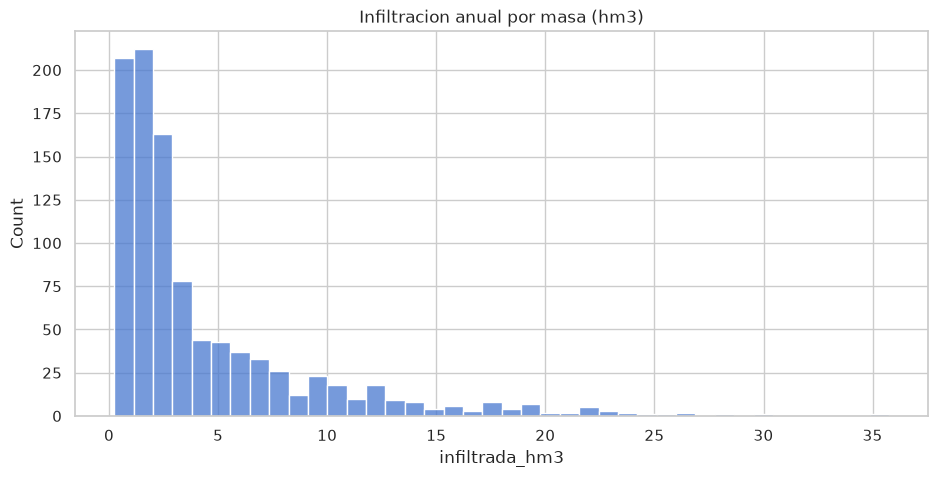

In [5]:
sns.histplot(anual["infiltrada_hm3"].to_pandas(), bins=40)
plt.title("Infiltracion anual por masa (hm3)")
plt.show()


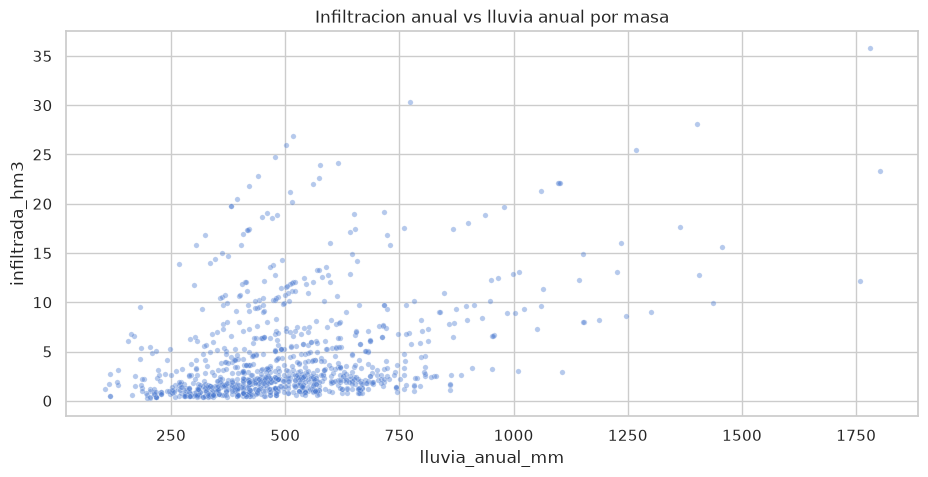

In [6]:
# Relacion lluvia vs infiltracion (coeficiente por masa)
ll = pl.read_csv(DATA / "lluvia_masa_subterranea.csv", infer_schema_length=None)
ll_anual = ll.group_by(["cod_masa", "anio"]).agg(pl.col("precipitacion_mm").sum().alias("lluvia_anual_mm"))
cmp = anual.join(ll_anual, on=["cod_masa", "anio"], how="inner")
sns.scatterplot(data=cmp.to_pandas(), x="lluvia_anual_mm", y="infiltrada_hm3", alpha=0.4, s=15)
plt.title("Infiltracion anual vs lluvia anual por masa")
plt.show()


**Conclusiones EDA**

- 84 masas con coeficientes de infiltracion (3 masas sin coef quedan fuera). Serie mensual 2015-2026.
- La infiltracion es proporcional a la lluvia con factor por masa (areas y coeficientes constantes) — como feature es **colineal** con `lluvia_anual_mm`; en v1 no se incluye en el modelo de consumo (se mantiene para el balance hidrico).
